In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [15]:
df = pd.read_csv("../data/raw/mental_health_burnout_tech_2026.csv")
print("Shape:", df.shape)

Shape: (100000, 36)


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   country                      100000 non-null  str    
 4   job_role                     100000 non-null  str    
 5   seniority_level              100000 non-null  str    
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  str    
 9   industry                     100000 non-null  str    
 10  work_mode                    100000 non-null  str    
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 non-null  int64  
 13  meetings_pe

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,100000.0,50000.500000,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,31.305670,6.427924,22.0,26.00,31.0,36.00,55.0
years_experience,100000.0,9.343690,6.401543,0.0,4.00,9.0,14.00,25.0
years_at_company,100000.0,2.492581,2.450426,0.1,0.70,1.7,3.50,15.0
salary_usd,100000.0,83285.490230,39392.584827,40000.0,46018.25,76630.5,109113.00,267961.0
work_hours_per_week,100000.0,47.104080,5.246902,35.0,44.00,47.0,51.00,72.0
meetings_per_day,100000.0,4.162244,1.937849,0.0,2.80,4.0,5.40,12.0
team_size,100000.0,18.009650,12.607473,2.0,8.00,16.0,25.00,59.0
sleep_hours_per_night,100000.0,6.102392,0.998808,3.0,5.40,6.1,6.80,10.0
exercise_days_per_week,100000.0,2.968730,1.772762,0.0,2.00,3.0,4.00,7.0


In [20]:
df.describe(include='object').T

/tmp/ipykernel_946926/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
gender,100000,4,Male,65243
country,100000,10,USA,31966
job_role,100000,12,Software Engineer,20080
seniority_level,100000,6,Mid,28092
company_size,100000,5,Mid (201-1000),25062
industry,100000,10,SaaS / Cloud,19957
work_mode,100000,3,Hybrid,39856
phq9_category,100000,5,None (0-4),40918
gad7_category,100000,4,Minimal (0-4),47532
burnout_level,100000,4,Severe,28576


In [21]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: float64)

In [22]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n=== {col} ({df[col].nunique()} unique values) ===")
    print(df[col].value_counts(dropna=False).head(10))


=== gender (4 unique values) ===
gender
Male                 65243
Female               29759
Non-binary            3994
Prefer not to say     1004
Name: count, dtype: int64

=== country (10 unique values) ===
country
USA            31966
India          21998
UK              9939
Canada          7940
Germany         7099
Australia       6169
Brazil          4050
Netherlands     3956
Singapore       3947
France          2936
Name: count, dtype: int64

=== job_role (12 unique values) ===
job_role
Software Engineer         20080
Data Scientist            12029
ML Engineer               10114
Data Analyst               8028
Backend Developer          7996
Frontend Developer         7970
Product Manager            7965
DevOps Engineer            7949
Full Stack Developer       6907
Cybersecurity Engineer     4011
Name: count, dtype: int64

=== seniority_level (6 unique values) ===
seniority_level
Mid          28092
Senior       24852
Junior       20230
Lead         11928
Manager       9915

/tmp/ipykernel_946926/1174122388.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [23]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}, nunique={df[col].nunique()}")

employee_id: min=1, max=100000, mean=50000.50, nunique=100000
age: min=22, max=55, mean=31.31, nunique=34
years_experience: min=0, max=25, mean=9.34, nunique=26
years_at_company: min=0.1, max=15.0, mean=2.49, nunique=150
salary_usd: min=40000, max=267961, mean=83285.49, nunique=58886
work_hours_per_week: min=35, max=72, mean=47.10, nunique=36
meetings_per_day: min=0.0, max=12.0, mean=4.16, nunique=120
team_size: min=2, max=59, mean=18.01, nunique=58
sleep_hours_per_night: min=3.0, max=10.0, mean=6.10, nunique=71
exercise_days_per_week: min=0, max=7, mean=2.97, nunique=8
vacation_days_taken: min=0, max=30, mean=12.05, nunique=31
therapy_access: min=0, max=1, mean=0.34, nunique=2
uses_therapy: min=0, max=1, mean=0.15, nunique=2
ai_tools_daily: min=0, max=1, mean=0.73, nunique=2
manager_support_score: min=1.0, max=10.0, mean=5.80, nunique=91
work_life_balance_score: min=1.0, max=10.0, mean=5.42, nunique=91
job_satisfaction_score: min=1.0, max=10.0, mean=4.83, nunique=91
social_support_sco

In [24]:
target_candidates = ["burnout_level", "seeks_mental_health_support", "job_change_intention"]

for t in target_candidates:
    if t in df.columns:
        print(f"\n=== {t} ===")
        print(df[t].value_counts(dropna=False))
    else:
        print(f"\n{t} NOT FOUND - check exact column name")


=== burnout_level ===
burnout_level
Severe      28576
Moderate    26255
Low         25807
High        19362
Name: count, dtype: int64

=== seeks_mental_health_support ===
seeks_mental_health_support
0    50211
1    49789
Name: count, dtype: int64

=== job_change_intention ===
job_change_intention
0    67998
1    32002
Name: count, dtype: int64


In [25]:
keywords = ["stress", "sleep", "meeting", "support", "manager", "supervisor",
            "satisf", "workload", "hours", "remote", "anxiety", "depress",
            "balance", "vacation", "leave", "exercise", "burnout", "cowork", 
            "seniority", "salary", "industry", "country", "role"]

for kw in keywords:
    matches = [c for c in df.columns if kw.lower() in c.lower()]
    if matches:
        print(f"[{kw}]: {matches}")

[stress]: ['stress_score']
[sleep]: ['sleep_hours_per_night']
[meeting]: ['meetings_per_day']
[support]: ['manager_support_score', 'social_support_score', 'seeks_mental_health_support']
[manager]: ['manager_support_score']
[satisf]: ['job_satisfaction_score']
[hours]: ['work_hours_per_week', 'sleep_hours_per_night']
[balance]: ['work_life_balance_score']
[vacation]: ['vacation_days_taken']
[exercise]: ['exercise_days_per_week']
[burnout]: ['burnout_score', 'burnout_level']
[seniority]: ['seniority_level']
[salary]: ['salary_usd']
[industry]: ['industry']
[country]: ['country']
[role]: ['job_role']


In [26]:
leakage_candidates = ["stress_score", "phq9_score", "gad7_score"]

for col in leakage_candidates:
    print(f"\nCorrelation of {col} with burnout_score:")
    print(df[col].corr(df["burnout_score"]))


Correlation of stress_score with burnout_score:
0.8538028034363313

Correlation of phq9_score with burnout_score:
0.7163831687162365

Correlation of gad7_score with burnout_score:
0.7167281079917975


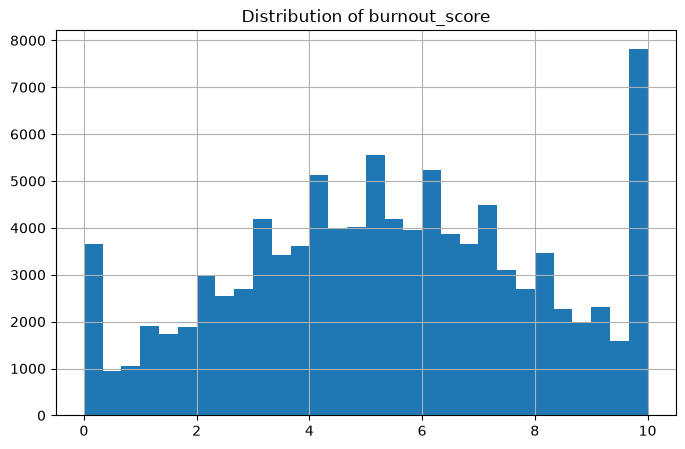

burnout_score              1.000000
work_hours_per_week        0.474050
meetings_per_day           0.455603
deadline_pressure_score    0.142685
job_satisfaction_score     0.056128
work_life_balance_score    0.000702
autonomy_score            -0.084505
manager_support_score     -0.168501
exercise_days_per_week    -0.206069
social_support_score      -0.219937
vacation_days_taken       -0.279164
sleep_hours_per_night     -0.338268
Name: burnout_score, dtype: float64


In [29]:
df["burnout_score"].describe()
df["burnout_score"].hist(bins=30, figsize=(8,5))
plt.title("Distribution of burnout_score")
plt.show()

final_features = [
    "work_hours_per_week", "meetings_per_day", "deadline_pressure_score",
    "autonomy_score", "manager_support_score", "social_support_score",
    "sleep_hours_per_night", "exercise_days_per_week", "vacation_days_taken",
    "work_life_balance_score", "job_satisfaction_score"
]

correlations = df[final_features + ["burnout_score"]].corr()["burnout_score"].sort_values(ascending=False)
print(correlations)

In [30]:
extra_cols = ["age", "years_experience", "years_at_company", "team_size", 
              "therapy_access", "uses_therapy", "ai_tools_daily", "salary_usd"]

correlations_extra = df[extra_cols + ["burnout_score"]].corr()["burnout_score"].sort_values(ascending=False)
print(correlations_extra)

burnout_score       1.000000
salary_usd          0.162126
ai_tools_daily      0.046055
team_size           0.001238
years_at_company   -0.001618
age                -0.002619
years_experience   -0.002742
therapy_access     -0.035772
uses_therapy       -0.055849
Name: burnout_score, dtype: float64


In [31]:
cat_cols_to_check = ["job_role", "seniority_level", "industry", "work_mode", "company_size"]

for col in cat_cols_to_check:
    print(f"\n=== Mean burnout_score by {col} ===")
    print(df.groupby(col)["burnout_score"].mean().sort_values(ascending=False))


=== Mean burnout_score by job_role ===
job_role
Product Manager           5.446679
Backend Developer         5.444785
Frontend Developer        5.422208
ML Engineer               5.415602
QA Engineer               5.405471
Cybersecurity Engineer    5.400100
Data Scientist            5.399900
DevOps Engineer           5.394666
Software Engineer         5.387779
Cloud Engineer            5.380904
Data Analyst              5.370391
Full Stack Developer      5.354727
Name: burnout_score, dtype: float64

=== Mean burnout_score by seniority_level ===
seniority_level
Manager      7.439909
Lead         7.434381
Principal    5.529300
Junior       4.802427
Senior       4.790681
Mid          4.768614
Name: burnout_score, dtype: float64

=== Mean burnout_score by industry ===
industry
AI / ML Startup          5.591486
Fintech                  5.576109
Gaming                   5.542385
Consulting               5.391258
SaaS / Cloud             5.333998
Enterprise Software      5.325763
Social Medi

In [32]:
extreme_low = df[df["burnout_score"] <= 0.5]
extreme_high = df[df["burnout_score"] >= 9.5]

print("Extreme LOW burnout cases - work_hours mean:", extreme_low["work_hours_per_week"].mean())
print("Extreme HIGH burnout cases - work_hours mean:", extreme_high["work_hours_per_week"].mean())
print("\nExtreme LOW count:", len(extreme_low))
print("Extreme HIGH count:", len(extreme_high))

Extreme LOW burnout cases - work_hours mean: 42.19334277620396
Extreme HIGH burnout cases - work_hours mean: 51.973547366041146

Extreme LOW count: 4236
Extreme HIGH count: 8846
